In [1]:
import argparse
import itertools
import json

In [30]:
import torch
import numpy as np 
from torch import nn
from rich.console import Group
from rich.live import Live
from rich.panel import Panel
from rich.progress import Progress
import matplotlib.pyplot as plt

from fintorch.deep.dtype import Dataset
from fintorch.deep.model import *
from fintorch.deep.module import Module
from fintorch.deep.transform.feature import *
from fintorch.deep.transform.label import *
from fintorch.exchange import ONLINE_EXCHANGE
from fintorch.enum import TimeFrame
from fintorch.deep.metrics import Metrics
from fintorch.setting import RICH_PROGRESS_COLUMNS
from fintorch.utils.timestamp import create_timestamps
from fintorch.utils.plot import draw_candlestick_plot, draw_labels

In [23]:
START_DATE = "2023-01-01"
STOP_DATE = "2024-01-01"

SYMBOL = "BTC-USDT"
TIME_FRAME = TimeFrame.DAY1

In [9]:
sdf = ONLINE_EXCHANGE.future.data.get_candles_dataframe(symbol=SYMBOL, time_frame=TIME_FRAME)
sdf

,open,high,low,close,volume,trade
timestamp,,,,,,
1569456000,8428.15,8464.40,7700.67,8060.15,60065.945,449
1569542400,8061.98,8260.00,7851.94,8176.52,40034.653,504
1569628800,8178.26,8311.00,8001.14,8195.38,33820.919,756
1569715200,8199.00,8226.35,7888.98,8041.96,35966.056,1138
1569801600,8042.08,8331.89,7709.01,8285.84,54412.520,751
...,...,...,...,...,...,...
1708387200,51813.70,53090.90,50788.00,52297.40,388913.064,21094
1708473600,52297.30,52402.30,50528.40,51877.80,308127.301,24735
1708560000,51877.90,52130.80,50967.50,51316.90,244144.647,40806


In [83]:
df = sdf.copy()
df["roc"] = df.close / df.open - 1
df["csroc"] = np.cumsum(df.roc)
df["msma"] = df.csroc.rolling(21, center=True).mean()
df["dif"] = df.msma.diff()

df["trend"] = 0.005 <= np.abs(df.dif)

print(df.trend.value_counts())
df

trend
False    869
True     744
Name: count, dtype: int64


,open,high,low,close,volume,trade,roc,csroc,msma,dif,trend
timestamp,,,,,,,,,,,
1569456000,8428.15,8464.40,7700.67,8060.15,60065.945,449,-0.043663,-0.043663,NaN,NaN,False
1569542400,8061.98,8260.00,7851.94,8176.52,40034.653,504,0.014207,-0.029456,NaN,NaN,False
1569628800,8178.26,8311.00,8001.14,8195.38,33820.919,756,0.002093,-0.027362,NaN,NaN,False
1569715200,8199.00,8226.35,7888.98,8041.96,35966.056,1138,-0.019154,-0.046516,NaN,NaN,False
1569801600,8042.08,8331.89,7709.01,8285.84,54412.520,751,0.030311,-0.016205,NaN,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...
1708387200,51813.70,53090.90,50788.00,52297.40,388913.064,21094,0.009335,2.839679,NaN,NaN,False
1708473600,52297.30,52402.30,50528.40,51877.80,308127.301,24735,-0.008021,2.831658,NaN,NaN,False
1708560000,51877.90,52130.80,50967.50,51316.90,244144.647,40806,-0.010814,2.820844,NaN,NaN,False


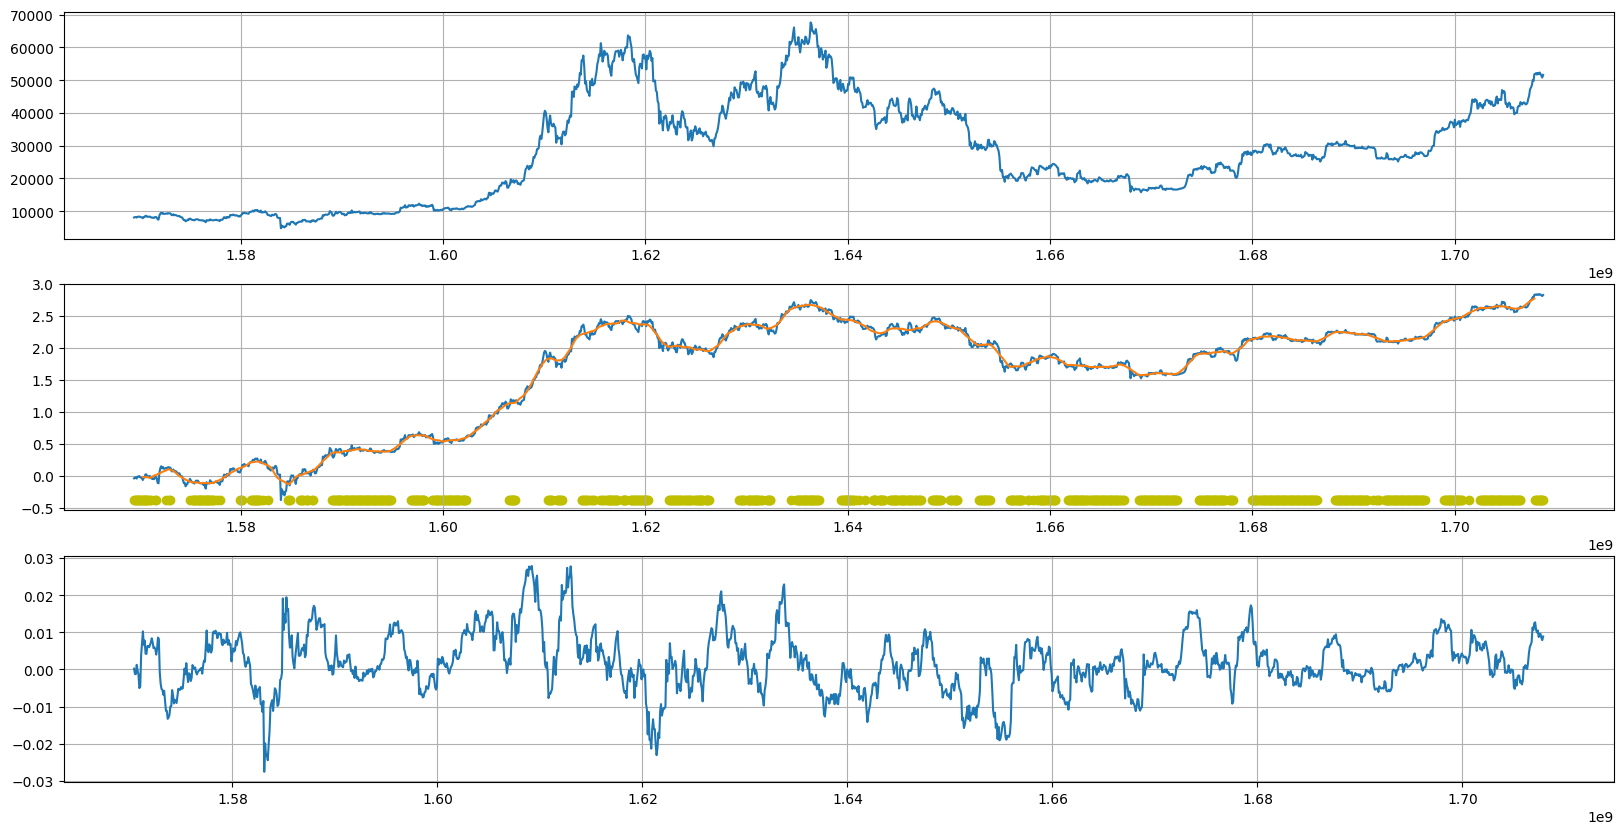

In [85]:
pdf = df.iloc[-500:]

fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(20, 10))

axs[0].plot(df.close)
axs[0].grid()


axs[1].plot(df.csroc)
axs[1].plot(df.msma)
x = df[~df.trend].index.to_list()
y = [df.csroc.min()] * len(x)
axs[1].scatter(x=x, y=y, color="y")
axs[1].grid()

axs[2].plot(df.dif)
axs[2].grid()